## Testing the library to load and manipulate a pre-built Magic The Gathering Card Deck

In [18]:
try:
    import pymtgdeck as mtg
    from pathlib import Path
    from matplotlib import pyplot as plt
    import numpy as np
except ImportError as e:
    print(f"Error {e}")

### Now load a demo deck using the Backend API

In [12]:
DECK_FILE: str = "demo_deck.json"

# instantiate a backend
deck_path: Path = Path(".")
backend: mtg.Backend = mtg.Backend(file_path=deck_path)

In [13]:
# load the deck from disk
demo_deck: mtg.Deck = backend.load(file_name=DECK_FILE)

# print statistics
print(f"Loaded deck {DECK_FILE}, containing {demo_deck.get_card_count()} cards.")

Loaded deck demo_deck.json, containing 34 cards.


### Display Converted Mana Cost Histogram

In [22]:
# get histogram
cmc_histogram, edges = mtg.deck_cmc_histogram(demo_deck)

# print values
print(f"Card Count: {cmc_histogram}")
print(f"Converted Mana Cost Buckets {edges}")


Card Count: [3 8 6 6 3 3 0 0 1]
Converted Mana Cost Buckets [0 1 2 3 4 5 6 7 8 9]


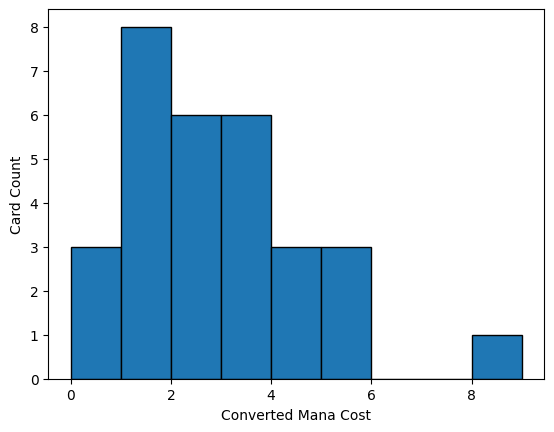

In [21]:
# plot histogram
fig, ax = plt.subplots()

# set labels
ax.set_xlabel("Converted Mana Cost")
ax.set_ylabel("Card Count")
ax.bar(edges[:-1], cmc_histogram, width=np.diff(edges), edgecolor="black", align="edge")

plt.show()